# 3.1 Coulomb's Law and the Electric Field

<!-- This single H1 (one per notebook, "# <number> <Title>") is the page's
     title: it sets the sidebar entry, breadcrumb, browser tab, and search
     result. The branded banner below is generated by the shared `ecp`
     package, so the look of every notebook in the series lives in one place. -->

In [1]:
from ecp.style import header, use_style

use_style()  # apply the series Matplotlib style
header(
    volume="Volume III — Classical Electrodynamics",
    number="3.1",
    title="Coulomb's Law and the Electric Field",
    blurb="The electric field as a vector field: Coulomb's inverse-square law, "
    "superposition, field lines, and the point charge as an idealised "
    "delta-function source. The computational vocabulary the rest of "
    "the volume is written in.",
    difficulty="intermediate",
    estimate="90–120 min",
)

<ECP header: 2578 chars of HTML>

## Notebook overview

Volume III opens by changing the question. Mechanics tracked particles; here the
protagonist is the **field**, a quantity defined at every point of space that a
charge placed there would feel. Coulomb's inverse-square law is the seed, but the
moment there is more than one charge the interesting object is no longer a force
between two bodies: it is the whole vector field $\mathbf E(\mathbf r)$ filling
space, the superposition of every source. Learning to build, plot, and probe that
field numerically is the real subject of this notebook, and the toolbox the rest
of the volume leans on.

We will represent a field as arrays on a grid, add fields by **superposition**,
trace **field lines** by integrating a streamline, and compute the **flux** of a
field through a surface, which turns out to equal the enclosed charge over
$\varepsilon_0$ and previews Gauss's law ([§3.3](gauss-law.ipynb)). Along the way we meet the point
charge in its honest mathematical clothing, the **Dirac delta**, developed not as
an assertion but as the limit of a narrowing Gaussian. That idealisation is what
makes the Green's-function solution of Poisson's equation possible in
[§3.4](laplace-poisson.ipynb), where
$\nabla^2(1/r) = -4\pi\,\delta^3(\mathbf r)$ makes the point charge the
fundamental solution. We thread the delta through the volume rather than isolating
it.

Everything is in **SI units**: $\varepsilon_0 = 8.854\times10^{-12}\,$F/m and
$k = 1/4\pi\varepsilon_0 \approx 8.99\times10^9\,$N·m²/C². Electrostatic fields do
not move, so every figure here is a faithful *static* plot: field lines at equal
angular spacing (whose density then encodes $|\mathbf E|$), or arrows whose length
and colour encode $|\mathbf E|$. A still picture shows a vector field better than
motion would.

> **How to read the checks.** Each exercise ends with a `validate` call against an
> independent fact: an inverse-square ratio, a symmetry cancellation, a flux that
> matches $q/\varepsilon_0$, a closed-form field. A ✓ is strong evidence; a ✗ is a
> prompt to *locate the discrepancy*, not a verdict.

> **Scope.** A working review, not a full electrodynamics course. The standard
> references are Nolting, *Theoretical Physics 3* {cite}`nolting3`, Griffiths,
> *Introduction to Electrodynamics* {cite}`griffiths_em`, and Jackson,
> *Classical Electrodynamics* {cite}`jackson` for depth.

## Theory in brief

### Coulomb's law and the electric field

Two point charges $q_1, q_2$ separated by $\mathbf r$ (pointing from $q_1$ to the
field point) repel or attract along the line joining them, with a force that falls
as the inverse square of the distance:

```{math}
:label: eq-coulomb
\mathbf F = \frac{1}{4\pi\varepsilon_0}\,\frac{q_1 q_2}{r^2}\,\hat{\mathbf r},
\qquad k \equiv \frac{1}{4\pi\varepsilon_0} \approx 8.99\times10^{9}\ \text{N·m}^2/\text{C}^2 .
```

Dividing out a test charge $q_{\text{test}}$ removes it from the discussion and
leaves a property of space alone, the **electric field**:

```{math}
:label: eq-field
\mathbf E(\mathbf r) = \frac{\mathbf F}{q_{\text{test}}}
= \frac{1}{4\pi\varepsilon_0}\,\frac{q}{r^2}\,\hat{\mathbf r},
```

the field of a single point charge $q$. It is defined everywhere (except at the
charge), and a test charge dropped in merely samples it. Numerically we represent
$\mathbf E$ as a pair of component arrays evaluated on a grid.

### Superposition

Maxwell's equations are linear, so fields add. The field of a collection of
charges is the vector sum of their individual point-charge fields, and for a
continuous distribution $\rho(\mathbf r')$ the sum becomes an integral:

```{math}
:label: eq-superposition
\mathbf E(\mathbf r) = \frac{1}{4\pi\varepsilon_0}
\sum_i q_i\,\frac{\mathbf r - \mathbf r_i}{|\mathbf r - \mathbf r_i|^3}
\;\longrightarrow\;
\frac{1}{4\pi\varepsilon_0}\int \rho(\mathbf r')\,
\frac{\mathbf r - \mathbf r'}{|\mathbf r - \mathbf r'|^3}\,d^3r' .
```

Linearity is what makes electrostatics tractable: build the field of anything by
adding the fields of its parts.

### Field lines

A **field line** is a curve everywhere tangent to $\mathbf E$. Parametrising it by
arc length $s$ gives the unit-speed streamline

```{math}
:label: eq-fieldline
\frac{d\mathbf r}{ds} = \frac{\mathbf E(\mathbf r)}{|\mathbf E(\mathbf r)|},
```

which we integrate as an ODE. Field lines begin on positive charges and end on
negative ones, and their local density encodes the field strength.

### The dipole

Two opposite charges $\pm q$ separated by a small displacement $\mathbf a$ (from
$-q$ to $+q$) form a **dipole**, with dipole moment

```{math}
:label: eq-dipole
\mathbf p = q\,\mathbf a, \qquad
E_{\text{axis}} \approx \frac{1}{4\pi\varepsilon_0}\,\frac{2p}{r^3}
\quad (r \gg a).
```

The far field falls as $1/r^3$, one power faster than a single charge, because the
charges nearly cancel (Griffiths {cite}`griffiths_em`, ch. 3, carries the
expansion out in full). The *ideal* (point) dipole is the limit $a\to0$ at fixed
$p$; for finite $a$ the on-axis field carries a small correction we will see
explicitly.

### The point charge as a delta source

A point charge is an idealisation: a finite charge $q$ squeezed to a single point.
Its charge density is written with the three-dimensional **Dirac delta**,

```{math}
:label: eq-delta
\rho(\mathbf r) = q\,\delta^3(\mathbf r - \mathbf r_0),
```

which is not a function but a **distribution**, defined by its *sifting* property
$\int f(\mathbf r)\,\delta^3(\mathbf r - \mathbf r_0)\,d^3r = f(\mathbf r_0)$. One
realises it as the limit of *nascent* functions: a Gaussian of unit integral whose
width $w\to0$ so that the peak diverges while the area stays $1$. The delta is the
bridge to the Green's-function solution of Poisson's equation in
[§3.4](laplace-poisson.ipynb), where
$\nabla^2(1/r) = -4\pi\,\delta^3(\mathbf r)$ makes the point charge the
fundamental solution of electrostatics.

## Setup

Setup holds the data — the SI constants $\varepsilon_0$ and $k = 1/4\pi\varepsilon_0$,
the nanocoulomb charge scale, the two conventional charge colours — and a single
instrument, a square grid builder for the field maps. This notebook's own machinery is
*not* here: you write the point-charge field `E_point` in Exercise 1 and the
superposition `E_field` in Exercise 2, and every later exercise is a question asked of
those two.

The Setup below holds this notebook's data and instruments — nothing you
are asked to build. It is collapsed so the building stays yours; expand it
whenever you want the details.

<!-- setup-policy: v2 -->

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

from ecp import draw, validate

# data: SI constants used throughout the volume.
from scipy.constants import epsilon_0 as EPS0  # vacuum permittivity, F/m

K = 1.0 / (4.0 * np.pi * EPS0)  # data: Coulomb constant ≈ 8.99e9 N·m²/C²
print(f"ε₀ = {EPS0:.4e} F/m")
print(f"k = 1/4πε₀ = {K:.4e} N·m²/C²")

# data: conventional colours — positive charge red, negative charge dark blue.
POS, NEG = "#c1121f", "#16213e"


# instrument: where to sample a field is bookkeeping, not physics — this only lays
# down a square meshgrid for the field maps, and no exercise here is about choosing
# a grid.
def field_grid(n=400, half=0.5):
    """A square coordinate grid centred on the origin.

    Parameters
    ----------
    n : int, optional
        Points per side (default ``400``).
    half : float, optional
        Half-width of the domain in metres (default ``0.5``), so the grid spans
        ``[-half, half]`` on each axis.

    Returns
    -------
    X, Y : numpy.ndarray
        The 2-D meshgrid coordinate arrays.
    """
    xs = np.linspace(-half, half, n)
    return np.meshgrid(xs, xs)


NANO = 1e-9  # data: 1 nC, the charge scale used throughout

ε₀ = 8.8542e-12 F/m
k = 1/4πε₀ = 8.9876e+09 N·m²/C²


## Exercise 1 — The field of a point charge

The whole volume rests on one field, so we
start by building it and confirming it behaves. A single charge produces a purely
radial field whose magnitude obeys the inverse-square law of {eq}`eq-coulomb` and
{eq}`eq-field`, the fingerprint we check first.

Written out in Cartesian components, the field {eq}`eq-field` of a charge $q$ sitting
at $\mathbf r_0 = (x_0, y_0)$, evaluated in the $z = 0$ plane, is
$k q\,(x - x_0)/d^3$ and $k q\,(y - y_0)/d^3$ with $d = |\mathbf r - \mathbf r_0|$.
It diverges at the charge itself, and the honest thing to do numerically is to let
that divergence appear as `inf`/`nan` (silence NumPy with `numpy.errstate`) and leave
the masking to whoever plots it, rather than smoothing the singularity away where it
cannot be seen. The configuration below is a single charge $q = 1\,$nC at the origin.

1. Write `E_point(q, r0, X, Y)`, returning the two in-plane components of that
   field in V/m on the coordinate grids `X`, `Y`. **Write this one yourself** — the
   implementation is the lesson: this force law is the seed of the whole volume.
2. Sample the magnitude at $r = 0.1, 0.2, 0.4\,$m along the $x$-axis and
   verify that halving the distance quadruples the field, i.e.
   $E(0.1)/E(0.2) = 4$.
3. Draw the field over $[-0.5, 0.5]^2\,$m as lines seeded at equal angles around
   the charge ({numref}`fig-coulomb-point`), whose density then encodes
   $|\mathbf E|$.

In [3]:
# (solution hidden on the public site)


|E| at r = 0.1, 0.2, 0.4 m:  [898.75517862 224.68879465  56.17219866] V/m
E(0.1)/E(0.2) = 4.0000   E(0.2)/E(0.4) = 4.0000   (expect 4)


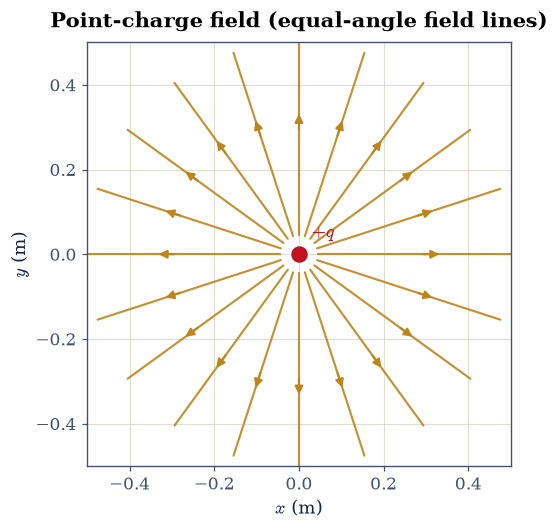

In [4]:
# (solution hidden on the public site)


### Validation 1

In [5]:
validate.close(ratio_12, 4.0, "the point-charge field falls as 1/r²", rtol=1e-3)

✓  the point-charge field falls as 1/r²   [got 4 vs expected 4 (rtol=0.001, atol=1e-09)]


True

## Exercise 2 — Superposition and symmetry

Fields add, and adding them makes symmetry
visible. With two identical charges placed symmetrically about the origin, any
point on the perpendicular bisector feels two contributions whose sideways parts
are mirror images and must cancel, leaving a purely transverse field on the axis.
This is superposition {eq}`eq-superposition` doing the bookkeeping that, by hand,
would be a vector diagram.

Because Maxwell's equations are linear, "the field of many charges" needs no new
physics and no new formula: it is the plain sum {eq}`eq-superposition` of the
single-charge fields, term by term on the same grid. That one line of arithmetic is
what turns Exercise 1's force law into a tool for arbitrary sources, so it is worth
writing rather than importing. The configuration here is $q = +1\,$nC at
$(-0.1, 0)\,$m and $q = +1\,$nC at $(+0.1, 0)\,$m.

1. Write `E_field(charges, X, Y)`, which takes a list of `(q, (x0, y0))` entries and
   returns the summed in-plane components on the grid, each term evaluated with the
   `E_point` you wrote in Exercise 1. **Write this one yourself** — the
   implementation is the lesson.
2. Confirm that along the $y$-axis (the perpendicular bisector) the
   $x$-component vanishes by symmetry.
3. Map the total field of the pair ({numref}`fig-coulomb-pair`).

In [6]:
# (solution hidden on the public site)


max |Ex| on the y-axis = 0.00e+00 V/m   (expect 0)
typical |Ey| there      = 2.30e+02 V/m


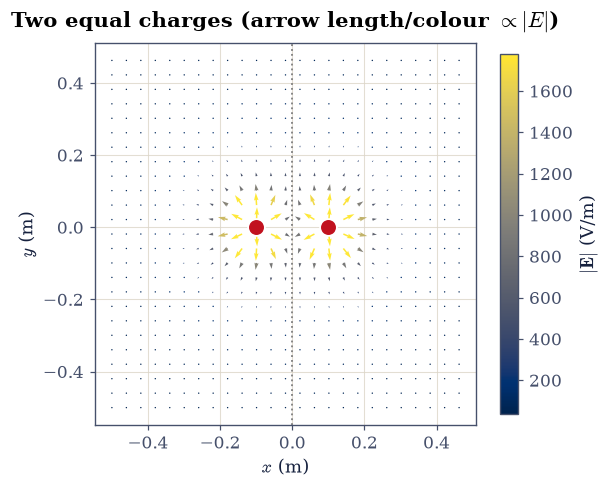

In [7]:
# (solution hidden on the public site)


### Validation 2

In [8]:
validate.close(
    Ex_axis,
    np.zeros_like(Ex_axis),
    "the transverse field cancels on the symmetry axis",
    atol=1e-9,
)

✓  the transverse field cancels on the symmetry axis   [max|Δ| = 0 (rtol=1e-06, atol=1e-09)]


True

## Exercise 3 — The electric dipole

Bring two *opposite* charges close together and the
monopole fields nearly cancel, leaving a characteristic field that falls as
$1/r^3$ ({eq}`eq-dipole`). The dipole is the first term in the systematic
description of any neutral charge distribution (the multipole expansion of [§3.5](multipole-expansion.ipynb)),
so its signature is worth meeting directly.

The configuration is $+1\,$nC at $(0, +0.01)\,$m and $-1\,$nC at $(0, -0.01)\,$m: a
separation $a = 0.02\,$m and a dipole moment $p = qa$.

1. Compute the on-axis field at $z = 0.1, 0.2\,$m with the `E_field` you wrote in
   Exercise 2.
2. Confirm the far-field $1/r^3$ falloff ($E(0.1)/E(0.2) = 8$).
3. Compare the magnitude with the ideal-dipole formula $2kp/r^3$. The small
   gap is the finite-separation correction: the ideal formula is the $a\to0$
   limit.

In [9]:
# (solution hidden on the public site)


on-axis |E| at z = 0.1, 0.2 m:  [366.8014197   45.16329313] V/m
E(0.1)/E(0.2) = 8.122   (expect 8 for 1/r³)
ideal 2kp/r³  at those z:       [359.50207145  44.93775893] V/m
finite-separation excess at z=0.1: 2.0%


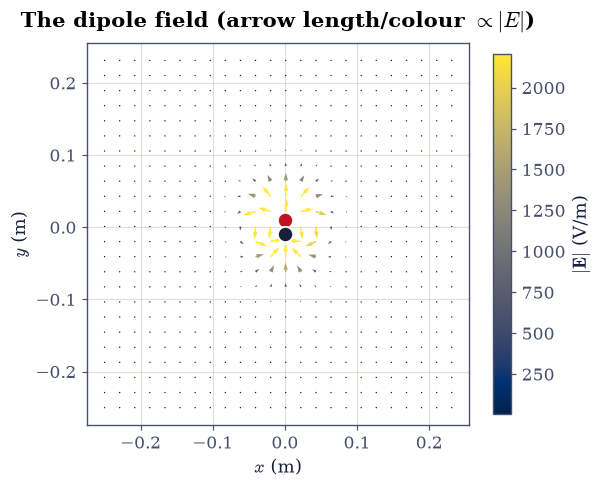

In [10]:
# (solution hidden on the public site)


### Validation 3

In [11]:
validate.close(ratio_dip, 8.0, "the dipole far-field falls as 1/r³", rtol=0.05)

✓  the dipole far-field falls as 1/r³   [got 8.12167 vs expected 8 (rtol=0.05, atol=1e-09)]


True

## Exercise 4 — Tracing field lines

A field map shows direction at sampled points; a
**field line** stitches those directions into a continuous curve, integrating
{eq}`eq-fieldline` from a seed point. Seeding the lines at *equal angles* around the
positive charge sends equal flux down each, so the resulting line density is itself
a faithful picture of the field strength.

Tracing one costs an ODE solve. Normalising the field to a unit vector makes arc
length the parameter, so the solver takes steps of *distance* rather than of field
strength and does not crawl where $|\mathbf E|$ is small. The line has to be told
where to stop, and the natural stopping point is the sink charge: a *terminal event*
(a function of position that changes sign when the line enters a small capture radius
around $-q$, with `terminal = True` and `direction = -1`) ends each integration
exactly there instead of letting it overshoot into the singularity. The dipole is the
one from Exercise 3.

1. Write `line_rhs(s, r)`, the right-hand side
   $d\mathbf r/ds = \mathbf E/|\mathbf E|$ of {eq}`eq-fieldline` for that dipole,
   evaluating $\mathbf E$ with the `E_field` you wrote in Exercise 2 and returning
   zero where the field vanishes. **Write this one yourself** — the implementation
   is the lesson.
2. Seed twelve points at equal angles on a small circle around the positive charge
   and integrate each with `scipy.integrate.solve_ivp` (a fine `max_step`,
   `rtol=1e-8`, `atol=1e-10`, `dense_output=True`), stopping on the terminal event
   at $-q$ and resampling each line uniformly in arc length.
3. Draw the completed lines as a static diagram ({numref}`fig-coulomb-lines`):
   every line that leaves $+q$ arrives at $-q$.

In [12]:
# (solution hidden on the public site)


field line 0 ends at [ 0.00399978 -0.01004208], distance to −q = 0.0040 m


With the lines traced, draw them as a single static diagram: each curve in full,
the charges as fixed markers.

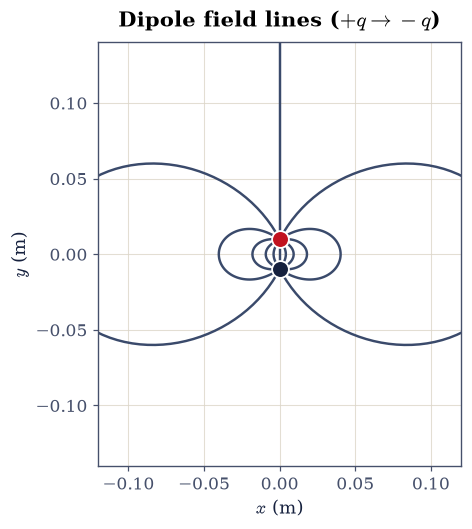

In [13]:
# (solution hidden on the public site)


### Validation 4

In [14]:
validate.check(
    end_dist < 0.02,
    "a field line seeded near +q terminates near −q",
    f"line end is {end_dist:.4f} m from −q",
)

✓  a field line seeded near +q terminates near −q   [line end is 0.0040 m from −q]


True

## Exercise 5 — The point charge as a delta source

A point charge holds a finite charge at a single
point, so its density {eq}`eq-delta` cannot be an ordinary function: it must be
zero everywhere yet integrate to $q$. The **Dirac delta** captures this as a
limit. The Gaussian
$g_w(x) = \exp(-x^2/2w^2)/(w\sqrt{2\pi})$ has unit integral for *every* width $w$,
and as $w\to0$ its peak diverges while the area stays exactly $1$. That limiting
object, defined by the sifting property
$\int f(x)\,\delta(x)\,dx = f(0)$, is the delta; in three dimensions
$\rho(\mathbf r) = q\,\delta^3(\mathbf r - \mathbf r_0)$.

The four widths sampled below are $w = 1, 0.3, 0.1, 0.03$.

1. Confirm with `numpy.trapezoid` that $\int g_w\,dx = 1$ at every width
   while the peak grows as $1/w$.
2. Plot the four Gaussians superposed on one axes
   ({numref}`fig-coulomb-delta`): the narrowing curves show the diverging
   peak and the constant unit area at a glance.

In [15]:
# (solution hidden on the public site)


w      : [1.   0.3  0.1  0.03]
∫g dx  : [1. 1. 1. 1.]  (expect 1)
peak   : [ 0.399  1.33   3.989 13.298]
peak·w : [0.3989 0.3989 0.3989 0.3989]  (constant 1/√2π = 0.3989)


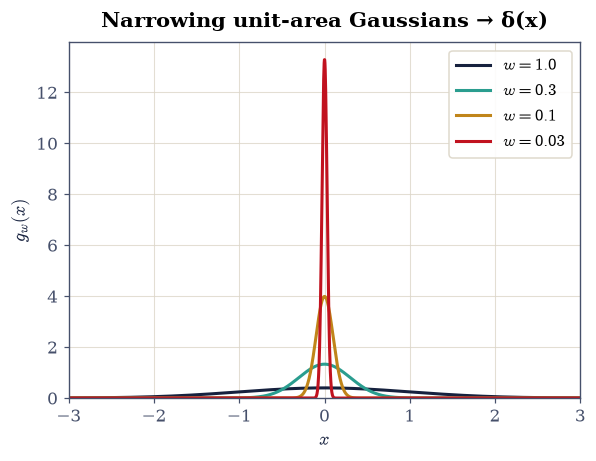

In [16]:
# (solution hidden on the public site)


### Validation 5

In [17]:
validate.close(
    areas,
    np.ones_like(areas),
    "every nascent-delta Gaussian has unit integral as it narrows",
    rtol=1e-3,
)
validate.close(
    peaks * widths,
    (1 / np.sqrt(2 * np.pi)) * np.ones_like(widths),
    "the nascent-delta peak grows as 1/w",
    rtol=1e-6,
)

✓  every nascent-delta Gaussian has unit integral as it narrows   [max|Δ| = 1.97318e-09 (rtol=0.001, atol=1e-09)]
✓  the nascent-delta peak grows as 1/w   [max|Δ| = 5.55112e-17 (rtol=1e-06, atol=1e-09)]


True

## Exercise 6 — Gauss's law previewed: flux of a point charge (student exercise)

Here is the integral that organises all of
electrostatics, and it is yours to compute. The **flux** of $\mathbf E$ through a
closed surface, $\oint \mathbf E\cdot d\mathbf A$, measures the field streaming
outward through it. For a point charge the inverse-square falloff of the field and
the $r^2$ growth of a sphere's area cancel exactly, so the flux equals
$q/\varepsilon_0$ *regardless of the sphere's radius*. That radius-independence is
the integral signature of the delta source and the gateway to Gauss's law
([§3.3](gauss-law.ipynb)).

Doing the surface integral numerically means parametrising the sphere by
$(\theta, \varphi)$: the surface point is
$\mathbf r = R(\sin\theta\cos\varphi, \sin\theta\sin\varphi, \cos\theta)$, the full
3-D point-charge field there is $k q\,\mathbf r/R^3$, the outward unit normal is
$\hat{\mathbf n} = \mathbf r/R$, and the area element is
$dA = R^2\sin\theta\,d\theta\,d\varphi$ — the $\sin\theta$ is the whole geometry of
the sphere and is the term most often dropped. The charge is $q = 1\,$nC at the
origin, the spheres are concentric with $R = 0.2, 0.5, 1.0\,$m.

1. Write `flux_through_sphere(R, q, n_theta=240, n_phi=480)`, evaluating
   $\oint \mathbf E\cdot d\mathbf A$ with a double `numpy.trapezoid` over that
   $(\theta, \varphi)$ grid. **Write this one yourself** — the implementation is
   the lesson.
2. Confirm the flux equals $q/\varepsilon_0$ at every radius.

Because the check tests the *flux*, a ✗ means "re-examine the surface integral or
the field," never a plotting issue.

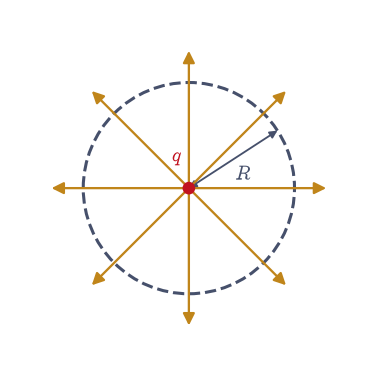

In [18]:
# (solution hidden on the public site)


In [19]:
# (solution hidden on the public site)


q/ε₀ = 1.1294e+02 V·m
R = 0.2 m:  flux = 1.1294e+02 V·m,  flux/(q/ε₀) = 0.99999
R = 0.5 m:  flux = 1.1294e+02 V·m,  flux/(q/ε₀) = 0.99999
R = 1.0 m:  flux = 1.1294e+02 V·m,  flux/(q/ε₀) = 0.99999


### Validation 6

In [20]:
validate.close(
    flux / expected,
    np.ones_like(flux),
    "the flux through any enclosing sphere is q/ε₀, independent of radius",
    rtol=1e-3,
)

✓  the flux through any enclosing sphere is q/ε₀, independent of radius   [max|Δ| = 1.43987e-05 (rtol=0.001, atol=1e-09)]


True

## Exercise 7 — A continuous distribution: the charged ring

Real sources are continuous, and superposition
{eq}`eq-superposition` handles them by integration. A uniformly charged ring is
the cleanest case: by symmetry its on-axis field is purely axial and has a tidy
closed form, $E_z = kQz/(z^2+R^2)^{3/2}$, against which we can check a numerical
integral over the distribution.

The ring makes the azimuthal integral unusually transparent. Every element of the
ring lies the same distance $d = \sqrt{R^2 + z^2}$ from an on-axis field point, and
the elements come in diametrically opposite pairs whose radial contributions cancel,
so only the axial component survives: with a charge per radian
$\lambda = Q/2\pi$, the integrand $dE_z/d\varphi = k\lambda z/d^3$ is constant in
$\varphi$. The source is a ring of radius $R = 0.05\,$m carrying total charge
$Q = 1\,$nC in the $z = 0$ plane.

1. Write `Ez_ring_numeric(z, n_phi=720)`, integrating that superposition
   {eq}`eq-superposition` over the azimuth with `numpy.trapezoid`. **Write this
   one yourself** — the implementation is the lesson.
2. Confirm it matches the closed form $E_z = kQz/(z^2+R^2)^{3/2}$ at
   $z = 0.02, 0.05, 0.1, 0.2\,$m.

{numref}`fig-coulomb-ring` shows the field in a plane through the axis, built
by superposing many point charges around the ring.

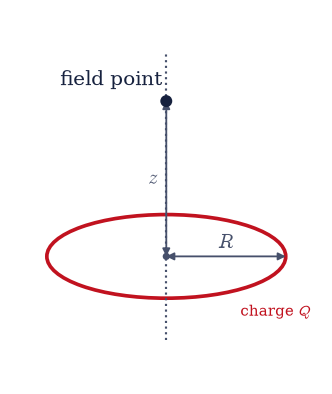

In [21]:
# (solution hidden on the public site)


In [22]:
# (solution hidden on the public site)


z (m)        : [0.02 0.05 0.1  0.2 ]
E_z numeric  : [1150.99756436 1271.03176285  643.09685585  205.15778729]
E_z closed   : [1150.99756436 1271.03176285  643.09685585  205.15778729]
max rel. diff: 4.44e-16


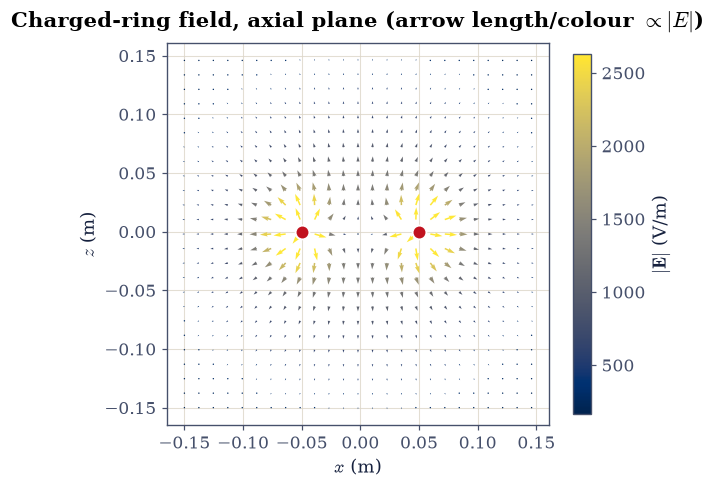

In [23]:
# (solution hidden on the public site)


### Validation 7

In [24]:
validate.close(
    Ez_num,
    Ez_closed,
    "the numerically integrated ring field matches the closed form",
    rtol=1e-4,
)

✓  the numerically integrated ring field matches the closed form   [max|Δ| = 2.27374e-13 (rtol=0.0001, atol=1e-09)]


True

## Exercise 8 — Numerical divergence of E (synthesis, forward to 3.3)

One last tool, introduced briefly and developed
fully in [§3.3](gauss-law.ipynb). Gauss's law has a local form, $\nabla\cdot\mathbf E = \rho/
\varepsilon_0$, which says the field has *sources* exactly where charge sits and is
**divergence-free** in empty space. We can compute $\nabla\cdot\mathbf E$
numerically from the field samples with finite differences and watch it vanish
away from the charge.

Two grid decisions carry the whole experiment. An *even* number of points per axis
keeps the origin between samples, so no node sits on the singular charge; and the
verdict is read off an empty-space shell $0.3 < r < 0.6\,$m, far enough from the
source that the field is smooth on the grid scale and inside the box, since
`numpy.gradient` falls back to one-sided, first-order differences on the boundary.
"Zero" for a numerical derivative is relative, so the divergence is compared with
the size of the individual terms $|\partial_x E_x| + |\partial_y E_y| +
|\partial_z E_z|$ that cancel to produce it.

1. Evaluate the point-charge field on such a grid and take its numerical
   divergence with `numpy.gradient`.
2. Confirm it is negligible compared with the size of its own derivative
   terms in that shell.

The spike of divergence *at* the charge is the delta of {eq}`eq-delta`, made
precise in [§3.3](gauss-law.ipynb).

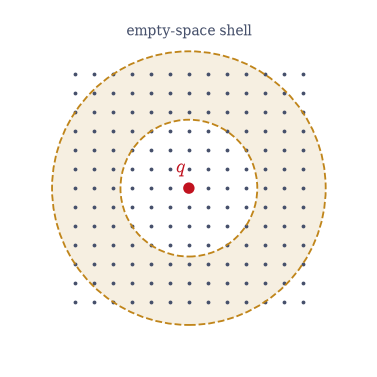

In [25]:
# (solution hidden on the public site)


In [26]:
# (solution hidden on the public site)


empty-space shell 0.3 < r < 0.6 m:
  RMS |∇·E| / RMS(|∂Ex|+|∂Ey|+|∂Ez|) = 3.881e-03
  the divergence is 258× smaller than its own derivative terms there


### Validation 8

In [27]:
validate.check(
    rel_div < 0.05,
    "the point-charge field is divergence-free in empty space (∇·E ≈ 0 away from the source)",
    f"RMS relative divergence in the empty-space shell = {rel_div:.3e}",
)

✓  the point-charge field is divergence-free in empty space (∇·E ≈ 0 away from the source)   [RMS relative divergence in the empty-space shell = 3.881e-03]


True

## Notebook summary

- The point-charge field $\mathbf E=kq\hat{\mathbf r}/r^2$ and its inverse-square fall
  ($E(0.1)/E(0.2)=4$), with superposition cancelling components by symmetry.
- The dipole's on-axis field $\propto 1/r^3$ ($E(0.1)/E(0.2)=8$); field lines traced from
  $d\mathbf r/ds=\mathbf E/|\mathbf E|$ and seeded at equal angles, so the line density
  faithfully encodes $|\mathbf E|$.
- The Dirac delta built as a unit-area Gaussian sequence; the flux of a point charge
  integrating to $q/\varepsilon_0$ (a Gauss's-law preview); the charged ring's on-axis
  field; and $\nabla\cdot\mathbf E$ taken numerically with `numpy.gradient`, the local
  law developed in [§3.3](gauss-law.ipynb).
- Tools introduced: `ecp.draw.radial_field_lines` and `ecp.draw.field_quiver` for
  physically faithful field plots, never a `streamplot` density artefact.

## Outlook

- **More elaborate distributions.** The same superposition integral handles
  surfaces and volumes; solid-angle arguments often replace the integral with a
  geometric picture.
- **Earnshaw's theorem.** Because $\nabla\cdot\mathbf E = 0$ in empty space, no
  arrangement of fixed charges can trap another charge in stable equilibrium, a
  clean impossibility result that echoes the saddle-point arguments of
  [§2.7](../02-classical-mechanics/small-oscillations.ipynb).
- **Derivatives of the delta.** The ideal dipole is $-\mathbf p\cdot\nabla\delta$,
  the first in a tower of distributional derivatives that organise the multipole
  expansion of [§3.5](multipole-expansion.ipynb).
- **Forward links.** The potential ([§3.2](potential-energy.ipynb)) trades this
  vector field for a scalar; Gauss's law ([§3.3](gauss-law.ipynb)) makes the flux
  of this notebook a law; and the Green's-function solution of Poisson's
  equation ([§3.4](laplace-poisson.ipynb)) rests on
  $\nabla^2(1/r) = -4\pi\,\delta^3(\mathbf r)$, which makes the point charge the
  fundamental solution of electrostatics.

### References

```{bibliography}
:filter: docname in docnames
```

In [28]:
from ecp.style import footer

footer()

<ECP header: 1221 chars of HTML>